<a href="https://colab.research.google.com/github/ipavlopoulos/greek-letter-vision/blob/main/fCNN%2BSCL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
%%capture
!gdown 1CMcTsxSzz6vzvrq_OIwOJFtowI3KHPOa
!gdown 1JnaVPaqDA60zpT7gkq6VtIPf8nlBGi87
!unzip Timeline20250531.zip

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import cv2
import pandas as pd

image_folder = 'Timeline20250531/cliplets/'
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Function to preprocess images (resize, binariz, normalize eand flatten)
def preprocess_image(image_path, size=(64, 64)):
    # Load image and convert to grayscale
    img = Image.open(image_path).convert('L')
    img_np = np.array(img)

    # Binarization using Otsu's method
    _, img_bin = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert image: black on white background
    img_bin = 255 - img_bin

    # Resize to standard size
    img_resized = cv2.resize(img_bin, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    # Flatten and return
    return img_normalized.flatten()

# Preprocess all images
image_data = []
for img_file in image_files:
    try:
        processed_img = preprocess_image(img_file)
        image_data.append(processed_img)
    except Exception as e:
        print(f"Error processing image {img_file}: {e}")

image_data = np.array(image_data)

# Adding metadata
filenames = os.listdir('Timeline20250531/cliplets/')
data = pd.DataFrame({'filename': filenames})
data['letter'] = data.filename.apply(lambda x: x.split('_')[0])
data['TM'] = data.filename.apply(lambda x: int(x.split('_')[1]))
data['number'] = data.filename.apply(lambda x: x.split('_')[2].split('.')[0])

metadata = pd.read_csv('metadata.csv')

data['year'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Year ante quem'].values[0])
data['region'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Production Nome (supposed)'].values[0])

In [2]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms

# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64)):
    img = Image.open(image_path).convert('L') # Grayscale
    img_np = np.array(img)

    # Binarization using Otsu's method
    _, img_bin = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert image: black on white background
    img_bin = 255 - img_bin

    # Resize to standard size
    img_resized = cv2.resize(img_bin, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized # Return as 2D numpy array

# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Other'].copy()
unk_data_split = data[data['letter'] == 'Other'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    label_encoder.fit_transform(train_data_split['letter']), # Re-encode labels for this split if needed
    test_size=0.2,
    random_state=42,
    stratify=label_encoder.fit_transform(train_data_split['letter'])
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)


# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
    transforms.RandomErasing(p=0.5, value=0.5) # erase parts to approx. lacunae
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

# Create custom PyTorch dataset for 2D data with augmentation
class ImageDatasetAugmented(Dataset):
    def __init__(self, X, y=None, transform=None):
        self.X = X # Expecting numpy array of images
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            # Apply the transforms
            image = self.transform(image)

        # The transform pipeline includes ToTensor() and normalization, so 'image' is now a tensor
        if self.y is not None:
            return image, self.y[idx]
        else:
            return image


# Create DataLoaders for 2D data with augmentation
batch_size = 16
train_loader_2d_aug = DataLoader(ImageDatasetAugmented(X_train_2d, y_train_2d, transform=data_transform), batch_size=batch_size, shuffle=True)
val_loader_2d = DataLoader(ImageDatasetAugmented(X_val_2d, y_val_2d, transform=test_transform), batch_size=batch_size)
test_loader_2d = DataLoader(ImageDatasetAugmented(X_test_2d, y_test_2d, transform=test_transform), batch_size=batch_size)
unk_loader_2d = DataLoader(ImageDatasetAugmented(X_unk_2d, transform=test_transform), batch_size=batch_size) # Assuming unknown inference needs standard processing

In [3]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss as in Khosla et al. (2020)
    https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        features: tensor of shape [batch_size, embed_dim]
        labels: tensor of shape [batch_size]
        """
        device = features.device
        features = F.normalize(features, dim=1)

        batch_size = features.shape[0]

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask: remove self-comparisons
        mask = torch.eye(batch_size, dtype=torch.bool).to(device)
        similarity_matrix = similarity_matrix.masked_fill(mask, -1e9)

        # Positive mask: same label
        labels = labels.contiguous().view(-1, 1)
        positive_mask = torch.eq(labels, labels.T).to(device)

        # For each sample, compute log-softmax
        log_prob = F.log_softmax(similarity_matrix, dim=1)

        # Only keep positives
        mean_log_prob_pos = (positive_mask * log_prob).sum(1) / positive_mask.sum(1).clamp(min=1)

        # Final loss
        loss = -mean_log_prob_pos.mean()
        return loss

class CNN2D(nn.Module):
    def __init__(self, num_classes, image_size=(64, 64)):
        super(CNN2D, self).__init__()
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Calculate the size of the flattened features after conv and pooling
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, image_size[0], image_size[1]) # (batch_size, channels, height, width)
            dummy_output = self.pool3(self.relu(self.conv3(self.pool2(self.relu(self.conv2(self.pool1(self.relu(self.conv1(dummy_input)))))))))
            flattened_size = dummy_output.shape[1] * dummy_output.shape[2] * dummy_output.shape[3]

        self.fc1 = nn.Linear(flattened_size, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Remove the unsqueeze(1) call as ToTensor() already adds the channel dimension
        # x = x.unsqueeze(1) # Add a channel dimension (batch_size, 1, height, width)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_embeddings(self, x):
        """Return embeddings before the final classification layer"""
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return x   # <-- embeddings (size = 512)

In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimilarityWeightedSupConLoss(nn.Module):
    """Supervised Contrastive Loss with class-similarity-weighted negatives."""
    def __init__(self, S_class, temperature=0.07, lambda_weight=1.0, eps=1e-8):
        super().__init__()
        self.register_buffer("S_class", S_class.float())
        self.temperature = temperature
        self.lambda_weight = lambda_weight
        self.eps = eps
        C = S_class.shape[0]
        mask_offdiag = (~torch.eye(C, dtype=torch.bool, device=S_class.device))
        self.S_bar = S_class[mask_offdiag].mean().clamp(min=eps)

    def forward(self, features, labels):
        z = F.normalize(features, dim=1)
        sim = torch.matmul(z, z.t()) / self.temperature
        B = z.size(0)
        eye = torch.eye(B, device=features.device, dtype=torch.bool)
        sim = sim.masked_fill(eye, -1e9)
        y = labels.view(-1, 1)
        pos_mask = (y == y.t()) & (~eye)
        S_pairs = self.S_class[labels][:, labels]
        w = 1.0 + self.lambda_weight * (S_pairs / self.S_bar)
        neg_mask = (~pos_mask) & (~eye)
        w = w * neg_mask.float() + pos_mask.float() + eye.float()
        exp_sim = torch.exp(sim) * (1.0 - eye.float())
        denom = (w * exp_sim).sum(dim=1, keepdim=True).clamp(min=self.eps)
        log_prob = sim - torch.log(denom)
        pos_count = pos_mask.sum(dim=1).clamp(min=1)
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(dim=1) / pos_count
        loss = -mean_log_prob_pos.mean()
        return loss

def compute_prototypes(embeddings, labels, num_classes):
    protos = []
    for c in range(num_classes):
        v = embeddings[labels == c].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v)
    return np.stack(protos)  # [C, D]

def build_S_from_prototypes(model, loader, device, num_classes):
    model.eval()
    Z, Y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model.get_embeddings(x).cpu().numpy()
            Z.append(z); Y.append(y.numpy())
    Z = np.vstack(Z); Y = np.concatenate(Y)
    P = compute_prototypes(Z, Y, num_classes)           # [C, D]
    # cosine similarity in [−1, 1] → clamp to [0,1]
    S = P @ P.T
    S = np.clip(S, 0.0, 1.0)
    np.fill_diagonal(S, 0.0)
    return torch.tensor(S, dtype=torch.float32, device=device)


def get_tta_embeddings(model, x, y, n_views, tta_transform, device):
    """Apply TTA safely to a batch."""
    B = x.size(0)
    x_aug_list = []
    for img in x:  # iterate over batch
        aug_imgs = [tta_transform(img.cpu()) for _ in range(n_views)]
        x_aug_list.extend(aug_imgs)
    x_aug = torch.stack(x_aug_list).to(device)
    y_aug = y.repeat(n_views)
    emb = model.get_embeddings(x_aug)
    return emb, y_aug

def train_cnn2d(model, train_loader, val_loader, device,
                num_classes, num_epochs=100, lam_scl_weight=0.1,
                n_views=2, tta_transform=None, use_swscl=True,
                use_tta=True, update_S_every=3, patience=10,
                save_path='best_cnn_letter_model.pth',
                learning_rate=0.001,
                similarity_matrix_fn=None,
                ema_alpha=0.0):
    """
    Train CNN2D with optional SW-SCL and TTA embeddings.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    ce_loss_fn = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses, val_accuracies = [], [], []

    if similarity_matrix_fn is None:
        similarity_matrix_fn = build_S_from_prototypes

    S_matrix = None
    swscl_loss_fn = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # --- Update similarity matrix dynamically ---
        if use_swscl and (epoch % update_S_every == 0 or S_matrix is None):
            new_S = similarity_matrix_fn(model, train_loader, device, num_classes)
            if S_matrix is None or ema_alpha == 0.0:
                S_matrix = new_S
            else:
                S_matrix = ema_alpha * S_matrix + (1 - ema_alpha) * new_S
            swscl_loss_fn = SimilarityWeightedSupConLoss(S_matrix, temperature=0.07, lambda_weight=1.0)

        for x_orig, y in train_loader:
            x_orig, y = x_orig.to(device), y.to(device)

            # --- CE Loss ---
            logits = model(x_orig)
            ce_loss = ce_loss_fn(logits, y)

            # --- SW-SCL Loss ---
            if use_swscl:
                if use_tta and tta_transform is not None and n_views > 1:
                    emb, y_aug = get_tta_embeddings(model, x_orig, y, n_views, tta_transform, device)
                else:
                    emb, y_aug = model.get_embeddings(x_orig), y
                swscl_loss = swscl_loss_fn(emb, y_aug)
            else:
                swscl_loss = 0.0

            loss = ce_loss + lam_scl_weight * swscl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_orig.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = ce_loss_fn(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}, '
              f'Val Accuracy: {val_accuracy:.4f}')

        # --- Early stopping ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs.')
                break

    return train_losses, val_losses, val_accuracies

# TTA/augmentation for embeddings
tta_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    transforms.RandomResizedCrop(size=(64,64), scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

def custom_similarity_matrix(model, loader, device, num_classes):
    # e.g., compute S differently or add class-specific weighting
    S = build_S_from_prototypes(model, loader, device, num_classes)
    return S * 0.5  # example: scale similarity

num_classes_2d = len(label_encoder.classes_)
image_input_size = (64, 64)  # Match preprocess_image_2d size
model = CNN2D(num_classes=num_classes_2d, image_size=image_input_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # Move model to the device

train_losses, val_losses, val_accs = train_cnn2d(
    model, train_loader_2d_aug, val_loader_2d, device, num_classes_2d,
    use_swscl=True, use_tta=True, tta_transform=tta_transform,
    similarity_matrix_fn=custom_similarity_matrix
)

Epoch [1/100] Train Loss: 2.4880, Val Loss: 1.1056, Val Accuracy: 0.6676
Epoch [2/100] Train Loss: 2.1435, Val Loss: 1.0203, Val Accuracy: 0.7059
Epoch [3/100] Train Loss: 2.0055, Val Loss: 0.9194, Val Accuracy: 0.7203
Epoch [4/100] Train Loss: 1.6388, Val Loss: 0.9526, Val Accuracy: 0.6983
Epoch [5/100] Train Loss: 1.8662, Val Loss: 0.9179, Val Accuracy: 0.7165
Epoch [6/100] Train Loss: 1.7932, Val Loss: 0.9373, Val Accuracy: 0.7165
Epoch [7/100] Train Loss: 1.4723, Val Loss: 0.9130, Val Accuracy: 0.7270
Epoch [8/100] Train Loss: 1.7321, Val Loss: 0.8287, Val Accuracy: 0.7452
Epoch [9/100] Train Loss: 1.6760, Val Loss: 0.8695, Val Accuracy: 0.7270
Epoch [10/100] Train Loss: 1.3847, Val Loss: 0.7534, Val Accuracy: 0.7596
Epoch [11/100] Train Loss: 1.6666, Val Loss: 0.7741, Val Accuracy: 0.7538
Epoch [12/100] Train Loss: 1.6351, Val Loss: 0.7714, Val Accuracy: 0.7605
Epoch [13/100] Train Loss: 1.3205, Val Loss: 0.7504, Val Accuracy: 0.7672
Epoch [14/100] Train Loss: 1.5936, Val Loss: 0.

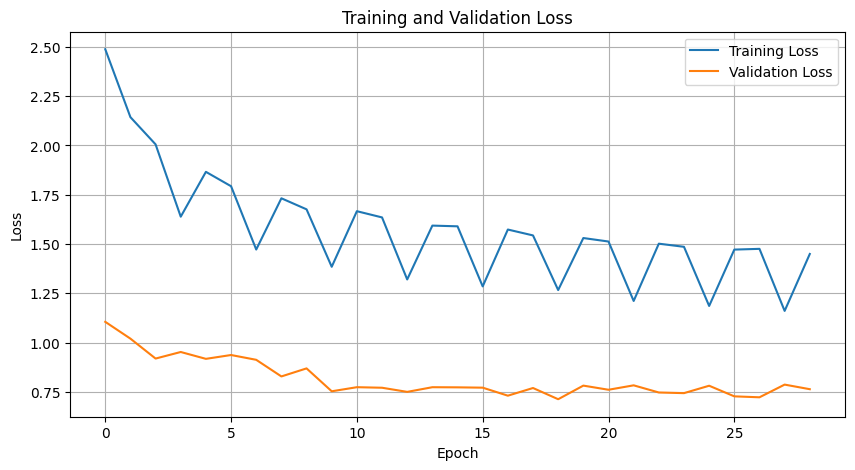

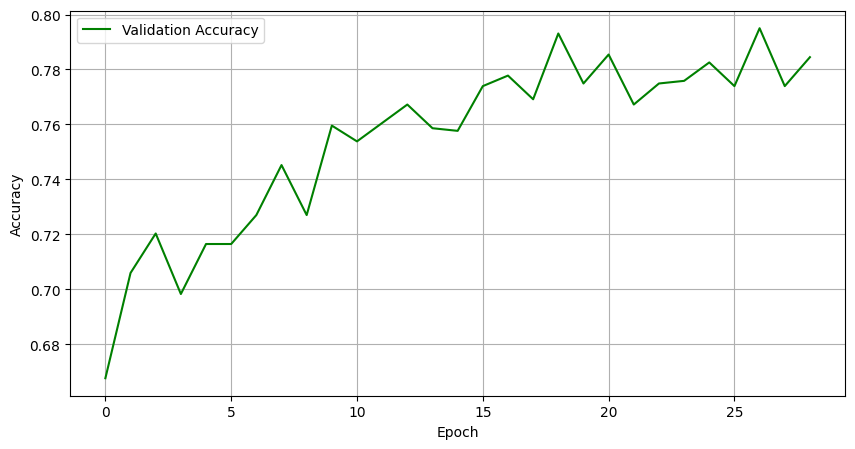


Classification Report on Test Data:
              precision    recall  f1-score   support

       Alpha       0.66      0.55      0.60       139
        Beta       0.82      0.75      0.78        67
         Chi       0.87      0.88      0.88        85
       Delta       0.71      0.81      0.75       113
     Epsilon       0.82      0.84      0.83       138
         Eta       0.67      0.81      0.73       124
       Gamma       0.75      0.72      0.73       106
        Iota       0.75      0.69      0.72       141
       Kappa       0.86      0.87      0.86       127
      Lambda       0.66      0.57      0.61       117
          Mu       0.84      0.81      0.82       126
          Nu       0.91      0.81      0.86       134
       Omega       0.73      0.86      0.79       126
     Omicron       0.64      0.81      0.72       136
         Phi       0.88      0.87      0.87        83
          Pi       0.80      0.80      0.80       127
         Psi       0.67      0.71      0.69 

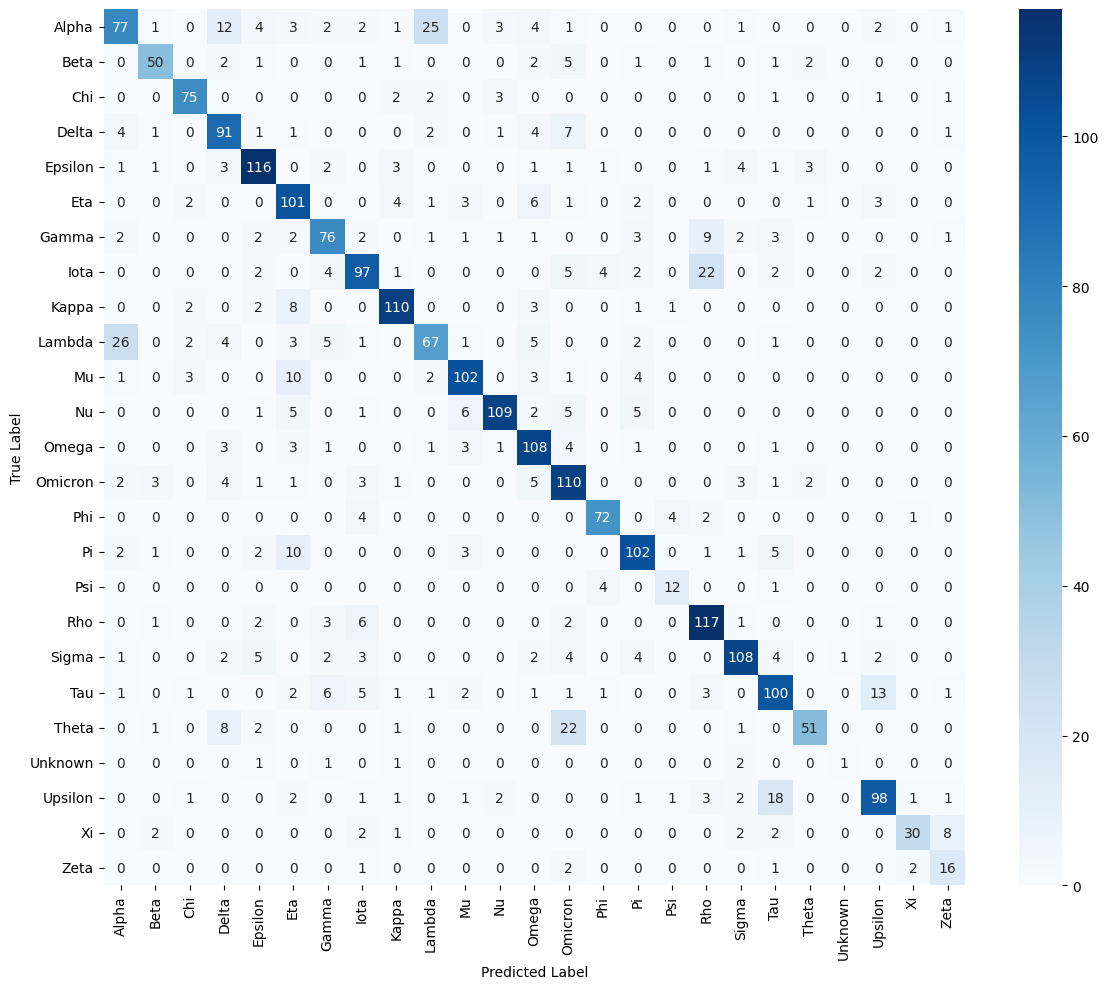


Predictions for 'Other' images:
Empty DataFrame
Columns: [filename, predicted_letter_2d_aug]
Index: []


In [11]:
# Load the best model state for inference
model.load_state_dict(torch.load('best_cnn_letter_model.pth'))

# Plotting training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(val_accs, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the 2D CNN on the test set
model.eval()
test_loss = 0.0
correct = 0
total = 0
predicted_labels_2d = []
true_labels_test_2d = []

with torch.no_grad():
    for inputs, labels in test_loader_2d:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        predicted_labels_2d.extend(predicted.cpu().numpy())
        true_labels_test_2d.extend(labels.cpu().numpy())


# Inverse transform the encoded predicted and true labels to get original letter names
predicted_letters_2d = label_encoder.inverse_transform(predicted_labels_2d)
true_letters_test_2d = label_encoder.inverse_transform(true_labels_test_2d)

# Display classification report
print("\nClassification Report on Test Data:")
print(classification_report(true_letters_test_2d, predicted_letters_2d, zero_division=0))

# Display confusion matrix
cm_2d = confusion_matrix(true_letters_test_2d, predicted_letters_2d, labels=label_encoder.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('cnn2d_aug_confusion_matrix.pdf', dpi=300, format='PDF')
plt.show()


# Make predictions on the 'Other' (Unknown) images
model.eval()
unk_predictions_2d = []
unk_filenames_2d = []

# Get filenames for the unknown data
unk_data_filenames = unk_data_split['filename'].tolist() # Use unk_data_split for filenames

with torch.no_grad():
    # Manually iterate through the unk_loader_2d to keep track of indices
    for i in range(len(unk_loader_2d.dataset)):
        inputs = unk_loader_2d.dataset[i].unsqueeze(0).to(device) # Get one image and add batch dim
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        # predicted is a tensor of size 1, get the item
        unk_predictions_2d.extend(predicted.cpu().numpy()) # Use extend and cpu().numpy()

# Inverse transform the predicted encoded labels to original letter names
predicted_unk_letters_2d = label_encoder.inverse_transform(unk_predictions_2d)

# Create a DataFrame to store unknown predictions
unk_predictions_df_2d = pd.DataFrame({
    'filename': unk_data_filenames, # Use the filenames from unk_data_split
    'predicted_letter_2d_aug': predicted_unk_letters_2d
})

print("\nPredictions for 'Other' images:")
print(unk_predictions_df_2d.head())

# merge these predictions back into τηε original data DataFrame if needed, eg:
# data = pd.merge(data, unk_predictions_df_2d, on='filename', how='left')